In [1]:
%load_ext autoreload
%autoreload 2

In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
from tqdm import tqdm

In [2]:
"""Script de entrenamiento para modelos de clasificación PET."""

import argparse
import os
import sys

import torch
from matplotlib import pyplot as plt
from torch import nn
from torchvision import models

# Importar módulos propios
from data.dataset import get_data_loaders
from utils.config_utils import load_config

# Añadir directorios al path
sys.path.append(os.path.dirname(os.path.dirname(os.getcwd())))

In [3]:
config_path = "configs/resnet18_2d_adni_cnad_server.yaml"

# Cargar configuración
config = load_config(config_path)

# Configurar dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Usando dispositivo: {device}")

# Obtener parámetros del modelo
model_config = config.get("model", {})
# model_name = model_config.get("name", "resnet18").lower()
# dimension = model_config.get("dimension", "2d").lower()

# Crear directorio para el experimento
# exp_base_dir = config.get("experiment", {}).get("base_dir", "./experiments")
# dataset_name = config.get("data", {}).get("dataset_name", "ADNI")
classes = config.get("data", {}).get("classes", "CN_AD")
# exp_name = config.get("experiment", {}).get("name", None)

# Crear modelo
num_classes = len(classes.split("_"))
model_config["num_classes"] = num_classes

# Obtener data loaders
train_loader, val_loader, test_loader = get_data_loaders(config)

Usando dispositivo: cuda
Configuración de clases: ['CN', 'AD'] (2 clases)
CSV cargado. Filas: 983
Usando columna 'Subject' para identificar sujetos
Usando columna 'Group' para diagnósticos
Valores únicos en 'Group': ['MCI', 'CN', 'AD']


Cargando dataset:   0%|          | 4/983 [00:00<00:34, 28.33it/s]

Cargando imagen: ./data/NIFTIs/Archivo/converted_niftis/018_S_4349.nii.gz
Dimensiones de la imagen: (128, 128, 35, 6)
Header de la imagen: <class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : np.bytes_(b'')
db_name         : np.bytes_(b'')
extents         : 0
session_error   : 0
regular         : np.bytes_(b'')
dim_info        : 0
dim             : [  4 128 128  35   6   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : float32
bitpix          : 32
slice_start     : 0
pixdim          : [1.   2.   2.   4.25 0.   1.   1.   1.  ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : np.bytes_(b'FreeSurfer Feb  5 2025')
aux_file        : np.bytes_(b'')
qform_

Cargando dataset: 100%|██████████| 983/983 [03:37<00:00,  4.52it/s]


Total de muestras cargadas: 544 de 544 sujetos

Distribución de clases:
  - CN: 272 muestras (50.0%)
  - AD: 272 muestras (50.0%)
CSV cargado. Filas: 112
Usando columna 'Subject' para identificar sujetos
Usando columna 'Group' para diagnósticos
Valores únicos en 'Group': ['MCI', 'AD', 'CN']


...

Total de muestras cargadas: 57 de 57 sujetos

Distribución de clases:
  - CN: 35 muestras (61.4%)
  - AD: 22 muestras (38.6%)
CSV cargado. Filas: 112
Usando columna 'Subject' para identificar sujetos
Usando columna 'Group' para diagnósticos
Valores únicos en 'Group': ['MCI', 'CN', 'AD']


Cargando dataset:   4%|▍         | 5/112 [00:00<00:02, 38.75it/s]

Cargando imagen: ./data/NIFTIs/Archivo/converted_niftis/012_S_5121.nii.gz
Dimensiones de la imagen: (128, 128, 35, 6)
Header de la imagen: <class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : np.bytes_(b'')
db_name         : np.bytes_(b'')
extents         : 0
session_error   : 0
regular         : np.bytes_(b'')
dim_info        : 0
dim             : [  4 128 128  35   6   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : float32
bitpix          : 32
slice_start     : 0
pixdim          : [  1.     2.     2.     4.25 300.     1.     1.     1.  ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : np.bytes_(b'FreeSurfer Feb  5 2025')
aux_file        : np.by

Cargando dataset: 100%|██████████| 112/112 [00:21<00:00,  5.11it/s]

Total de muestras cargadas: 57 de 57 sujetos

Distribución de clases:
  - CN: 34 muestras (59.6%)
  - AD: 23 muestras (40.4%)


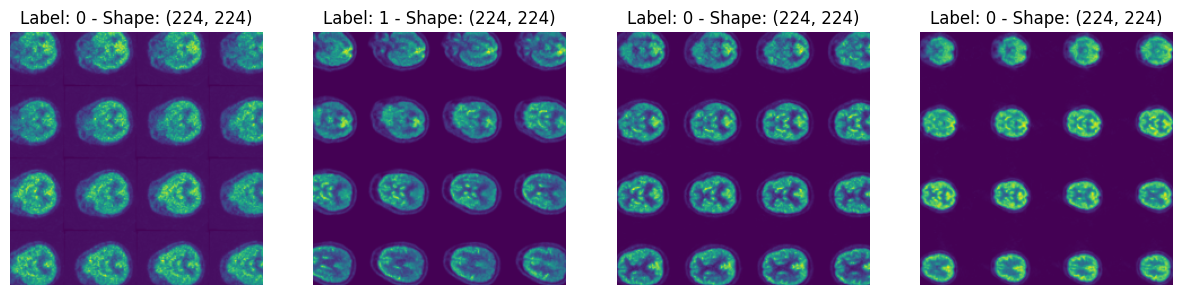

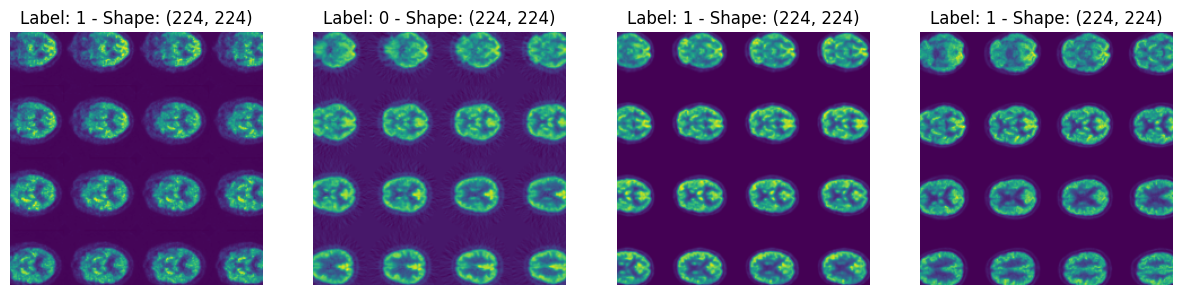

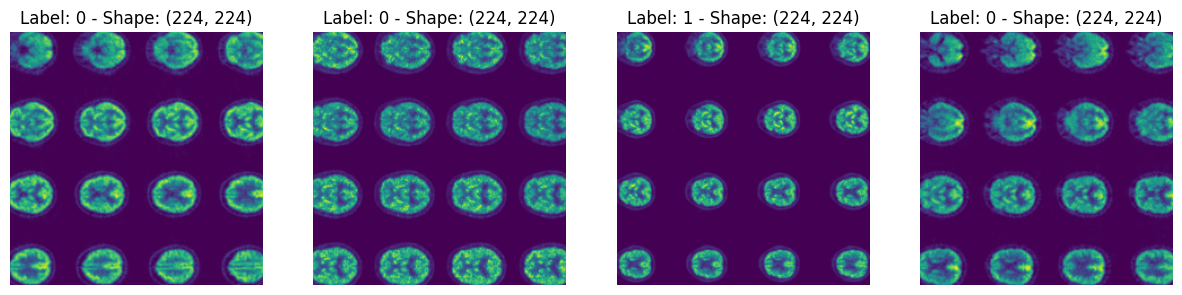

In [7]:
# Plot images from the training set
def plot_images(data_loader, num_images=4):

    images = []
    labels = []

    # Collect images and labels from the data loader
    for i, (image, label) in enumerate(data_loader):
        if i >= num_images:
            break
        images.append(image)
        labels.append(label)
    images = torch.stack(images)
    labels = torch.stack(labels)
    
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    for i in range(num_images):
        img = images[i].squeeze().cpu().numpy()
        # normalize the image to [0, 1] range for better visualization
        img = (img - img.min()) / (img.max() - img.min())
        img = img * 255
        if img.ndim == 4:
            img = img[0]
        img = img[0]

        axes[i].imshow(img, cmap='viridis')
        axes[i].set_title(f"Label: {torch.argmax(labels[i]).item()} - Shape: {img.shape}")
        axes[i].axis("off")
    plt.show()

# Plot images from the training set
plot_images(train_loader)
plot_images(val_loader)
plot_images(test_loader)

In [105]:
# Entrenar modelo
model = models.resnet18(weights="IMAGENET1K_V1")
# model = models.resnet18(weights=None)  # No usar pesos preentrenados
# model.fc = nn.Linear(model.fc.in_features, num_classes)

model.dropout = nn.Dropout(p=0.6)  # Añadir dropout
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, num_classes),
    nn.Softmax(dim=1)
)

model = model.to(device)

In [106]:
loss = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.00001)

In [107]:
model.eval()
for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)

    print(f"Labels: {labels}")
    print(f"Output: {outputs}")

    _, predicted = torch.max(outputs, 1)
    print(f"Predicted: {predicted}")
    print(f"ArgMax: {torch.argmax(outputs, dim=1)}")

    # Calcular matriz de confusión
    cm = confusion_matrix(torch.argmax(labels, dim=1).cpu().numpy(),
                          torch.argmax(outputs, dim=1).cpu().numpy(),
                            labels=list(range(num_classes)))

    print(f"Confusion Matrix:\n{cm}")

    break

Labels: tensor([[1., 0.]], device='cuda:0')
Output: tensor([[0.5591, 0.4409]], device='cuda:0', grad_fn=<SoftmaxBackward0>)
Predicted: tensor([0], device='cuda:0')
ArgMax: tensor([0], device='cuda:0')
Confusion Matrix:
[[1 0]
 [0 0]]


Epoch 100/100: 100%|██████████| 100/100 [03:28<00:00,  2.09s/it, train_accuracy=0.963, train_loss=0.352, val_accuracy=0.772, val_loss=0.538]


Best Validation Accuracy: 0.8421


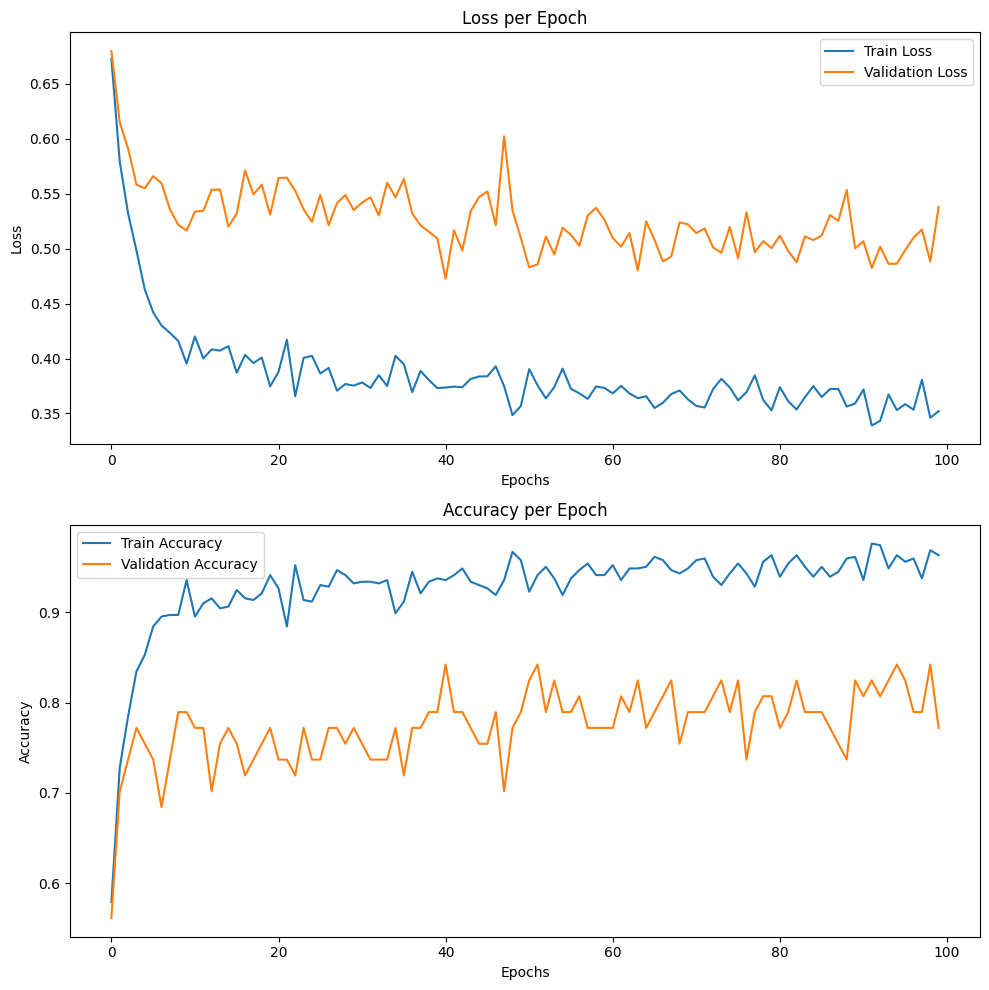

In [108]:
model.train()

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

epochs = 100

epoch_iterator = tqdm(range(epochs), desc="Training Progress")
for epoch in epoch_iterator:
    epoch_iterator.set_description(f"Epoch {epoch + 1}/{epochs}")

    corrects = 0
    total = 0

    batch_losses = []

    for batch in train_loader:
        # Entrenamiento
        model.train()
        inputs, labels = batch
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss_value = loss(outputs, labels)
        loss_value.backward()
        optimizer.step()

        preds = outputs.argmax(dim=1)
        trues = labels.argmax(dim=1)
        batch_corrects = (preds == trues).sum().item()

        corrects += batch_corrects
        total += labels.size(0)

        batch_losses.append(loss_value.item())

    train_loss = sum(batch_losses) / len(batch_losses)
    train_accuracy = corrects / len(train_loader.dataset)

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    model.eval()
    # Valid
    val_loss = 0.0
    val_corrects = 0
    val_total = 0

    for val_batch in val_loader:
        val_inputs, val_labels = val_batch
        val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)

        with torch.no_grad():
            outputs = model(val_inputs)
            v_loss = loss(outputs, val_labels)
            preds = outputs.argmax(dim=1)
            trues = val_labels.argmax(dim=1)
            v_corrects = (preds == trues).sum().item()

        val_corrects += v_corrects
        val_total += val_labels.size(0)
        val_loss += v_loss.item() * val_labels.size(0)

    val_loss /= val_total
    val_accuracy = val_corrects / val_total

    # save checkpoint
    if val_accuracy > max(val_accuracies, default=0):
        if not os.path.exists("checkpoints"):
            os.makedirs("checkpoints")
        torch.save(model.state_dict(), os.path.join(os.getcwd(), "checkpoints", "best_model.pth"))

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    # print(
    #     f"Epoch {epoch + 1}/{epochs}, Loss: {loss_value.item()}, Accuracy: {accuracy:.4f}, Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}"
    # )
    epoch_iterator.set_postfix(
        train_loss=train_loss,
        train_accuracy=train_accuracy,
        val_loss=val_loss,
        val_accuracy=val_accuracy,
    )

print(f"Best Validation Accuracy: {max(val_accuracies):.4f}")

# Plotear resultados
fig, axs = plt.subplots(2, 1, figsize=(10, 10))
axs[0].plot(train_losses, label="Train Loss")
axs[0].plot(val_losses, label="Validation Loss")
axs[0].set_title("Loss per Epoch")
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Loss")
axs[0].legend()

axs[1].plot(train_accuracies, label="Train Accuracy")
axs[1].plot(val_accuracies, label="Validation Accuracy")
axs[1].set_title("Accuracy per Epoch")
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Accuracy")
axs[1].legend()
plt.tight_layout()

plt.savefig("training_results.png")

In [109]:
best_model = models.resnet18(weights="IMAGENET1K_V1")
best_model.fc = nn.Sequential(
    nn.Linear(best_model.fc.in_features, num_classes), nn.Softmax(dim=1)
)
best_model = best_model.to(device)
# Cargar el mejor modelo guardado
best_model.load_state_dict(
    torch.load(os.path.join(os.getcwd(), "checkpoints", "best_model.pth"))
)
# Evaluar el mejor modelo en el conjunto de prueba
# best_model = model

best_model.eval()
with torch.no_grad():
    test_loss = 0.0
    test_corrects = 0
    test_total = 0
    for test_batch in test_loader:
        test_inputs, test_labels = test_batch
        test_inputs, test_labels = test_inputs.to(device), test_labels.to(device)

        outputs = best_model(test_inputs)
        t_loss = loss(outputs, test_labels)
        preds = outputs.argmax(dim=1)
        trues = test_labels.argmax(dim=1)
        t_corrects = (preds == trues).sum().item()
        test_corrects += t_corrects
        test_total += test_labels.size(0)
        test_loss += t_loss.item() * test_labels.size(0)

    test_loss /= test_total
    test_accuracy = test_corrects / test_total
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")


Test Loss: 0.5541, Test Accuracy: 0.7368


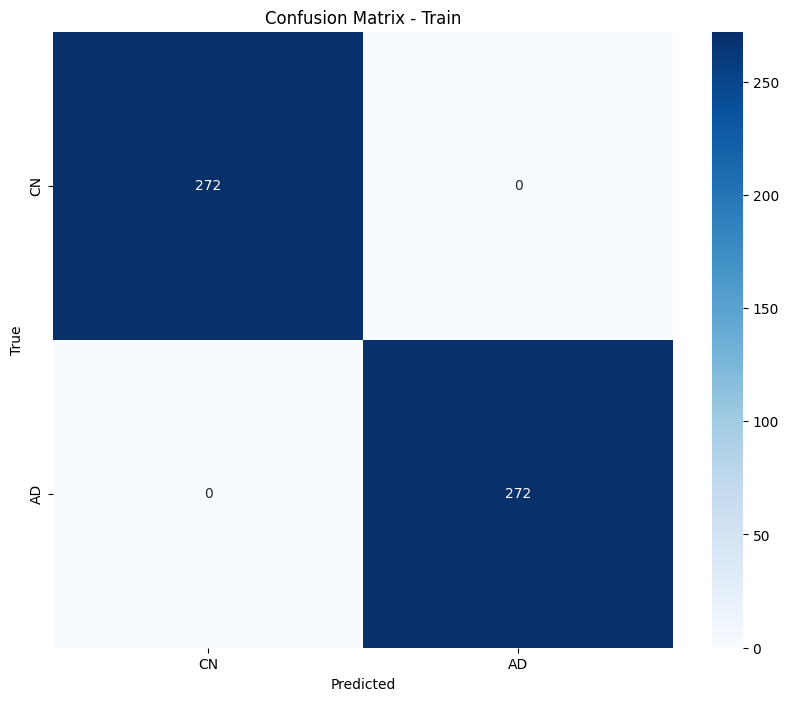

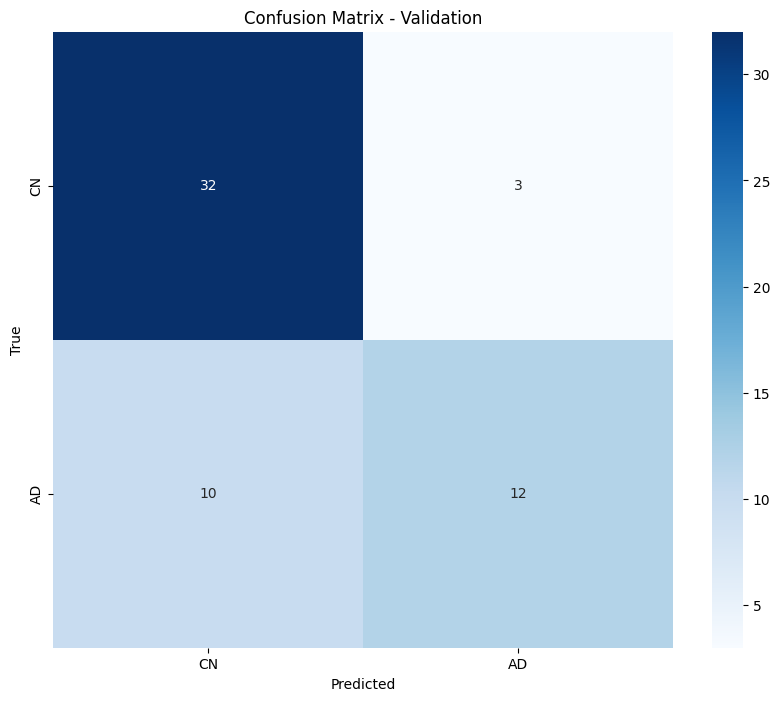

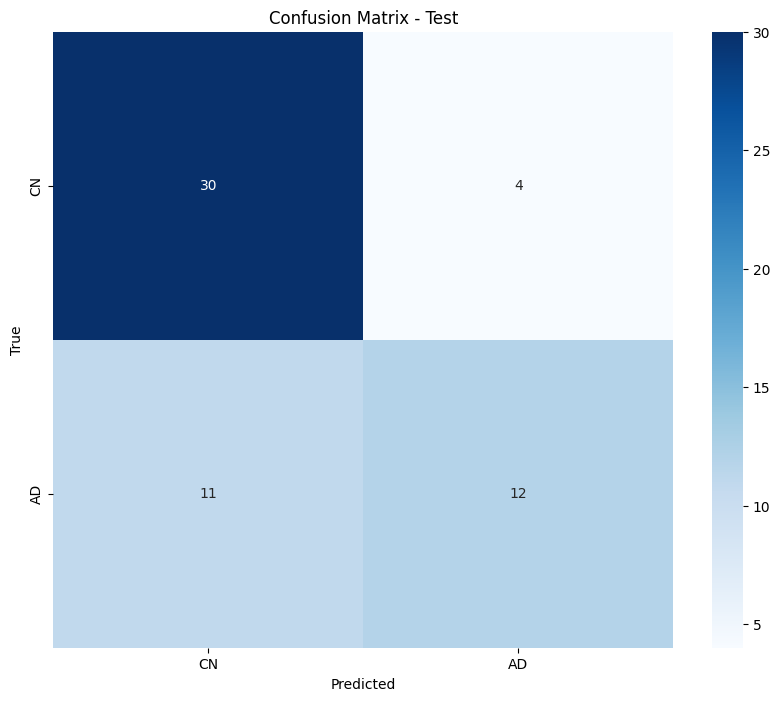

In [110]:
# Confusion matrix

def plot_confusion_matrix(y_true, y_pred, classes, set_name="Test"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix - " + set_name)
    plt.show()


# train
y_true = []
y_pred = []
for train_batch in train_loader:
    train_inputs, train_labels = train_batch
    train_inputs, train_labels = train_inputs.to(device), train_labels.to(device)

    with torch.no_grad():
        outputs = model(train_inputs)
        pred = outputs.argmax(dim=1)
        true = train_labels.argmax(dim=1) if train_labels.dim() > 1 else train_labels
        y_true.extend(true.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())
# Convertir a numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)
# Plotear matriz de confusión
plot_confusion_matrix(y_true, y_pred, classes.split("_"), set_name="Train")

# val
y_true = []
y_pred = []
for val_batch in val_loader:
    val_inputs, val_labels = val_batch
    val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)

    with torch.no_grad():
        outputs = model(val_inputs)
        pred = outputs.argmax(dim=1)
        true = val_labels.argmax(dim=1) if val_labels.dim() > 1 else val_labels
        y_true.extend(true.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())
# Convertir a numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)
# Plotear matriz de confusión
plot_confusion_matrix(y_true, y_pred, classes.split("_"), set_name="Validation")

# Obtener predicciones del conjunto de prueba
y_true = []
y_pred = []
for test_batch in test_loader:
    test_inputs, test_labels = test_batch
    test_inputs, test_labels = test_inputs.to(device), test_labels.to(device)

    with torch.no_grad():
        outputs = model(test_inputs)
        pred = outputs.argmax(dim=1)
        true = test_labels.argmax(dim=1) if test_labels.dim() > 1 else test_labels
        y_true.extend(true.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())

# Convertir a numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)
# Plotear matriz de confusión
plot_confusion_matrix(y_true, y_pred, classes.split("_"), set_name="Test")

In [ ]:
# 